In [ ]:
print("Handwritten digit recognition using a neural network")

Handwritten digit recognition using a neural network


In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [3]:
print(tf.__version__)

2.20.0


In [4]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)

print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


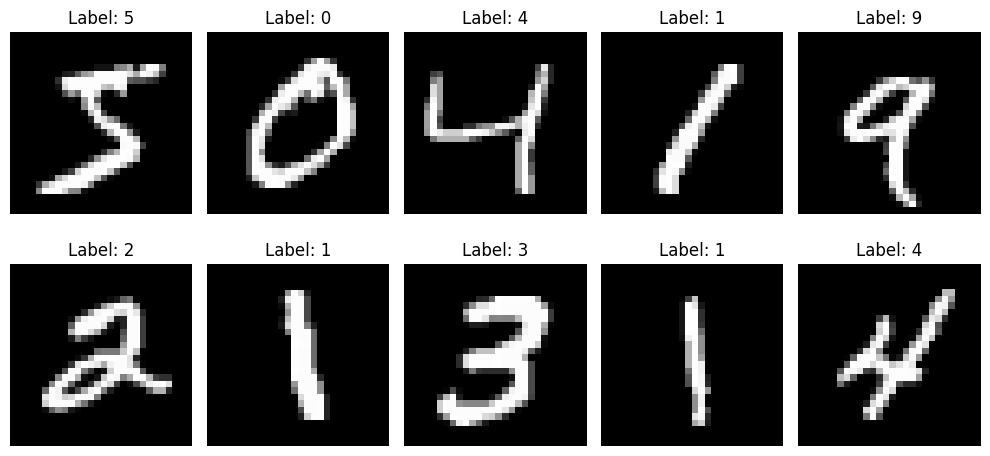

In [6]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print(X_train[0])

In [11]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [12]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [17]:
model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),

    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),

    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dense(10, activation='softmax')
])

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
loss='sparse_categorical_crossentropy'

In [22]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 48s 55ms/step - accuracy: 0.9476 - loss: 0.1701 - val_accuracy: 0.9845 - val_loss: 0.0519
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - accuracy: 0.9835 - loss: 0.0529 - val_accuracy: 0.9893 - val_loss: 0.0400
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 54ms/step - accuracy: 0.9889 - loss: 0.0361 - val_accuracy: 0.9897 - val_loss: 0.0343
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 85s 58ms/step - accuracy: 0.9914 - loss: 0.0261 - val_accuracy: 0.9902 - val_loss: 0.0374
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 55ms/step - accuracy: 0.9928 - loss: 0.0206 - val_accuracy: 0.9905 - val_loss: 0.0342
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 49s 58ms/step - accuracy: 0.9952 - loss: 0.0149 - val_accuracy: 0.9897 - val_loss: 0.0372
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 58ms/step - accuracy: 0.9964 - loss: 0.0117 - val_accuracy: 0.9902 - val_loss: 0.0399
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 54ms/step - accuracy: 0.9966 - loss: 0.0098 - 

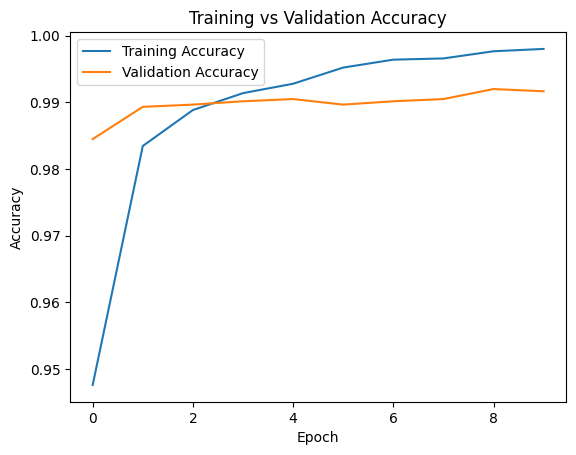

In [24]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

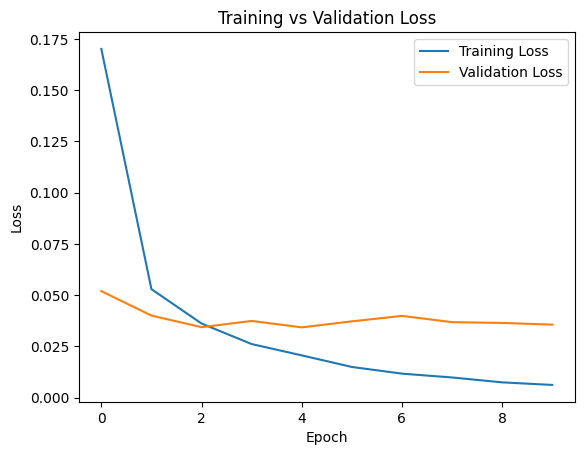

In [25]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [26]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9904 - loss: 0.0350
Test Loss: 0.03498253971338272
Test Accuracy: 0.9904000163078308


In [27]:
import numpy as np
import matplotlib.pyplot as plt

index = 0

image = X_test[index]
actual_label = y_test[index]

print("Actual digit:", actual_label)

Actual digit: 7


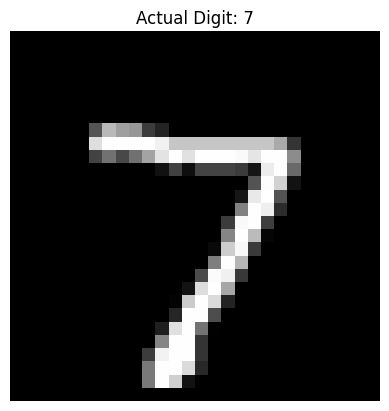

In [28]:
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Actual Digit: {actual_label}")
plt.axis('off')
plt.show()

In [29]:
image_batch = np.expand_dims(image, axis=0)

print(image_batch.shape)

(1, 28, 28, 1)


In [30]:
prediction = model.predict(image_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


In [31]:
print(prediction)

[[4.0429634e-12 2.1661249e-11 4.8455941e-11 1.3119520e-09 1.2142580e-16
  3.3651077e-13 6.0689279e-20 1.0000000e+00 4.0437174e-13 7.4217738e-10]]


In [32]:
predicted_label = np.argmax(prediction)

print("Predicted digit:", predicted_label)
print("Actual digit:", actual_label)

Predicted digit: 7
Actual digit: 7


In [33]:
confidence = np.max(prediction) * 100

print(f"Confidence: {confidence:.2f}%")

Confidence: 100.00%


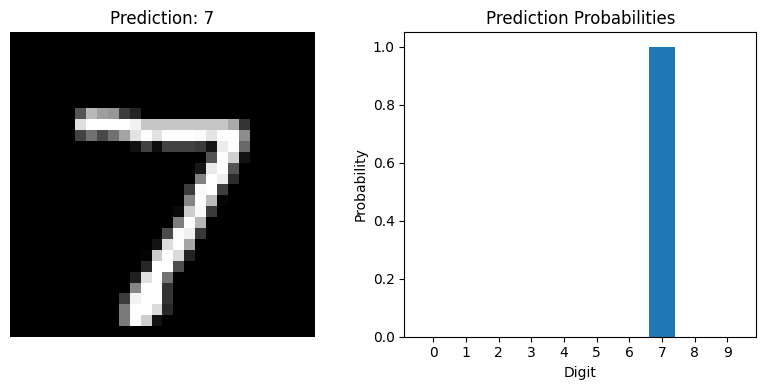

In [34]:
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Prediction: {predicted_label}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.bar(range(10), prediction[0])
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Probability")
plt.title("Prediction Probabilities")

plt.tight_layout()
plt.show()

In [35]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load your image
img = Image.open("/content/WhatsApp Image 2026-09-03 at 23.27.49.jpeg")

print(img.size)

(1204, 1600)


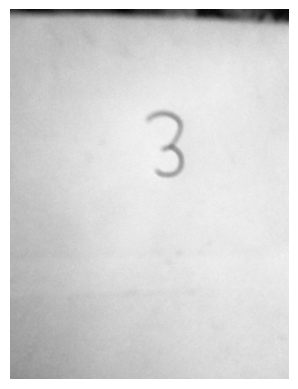

In [36]:
img_gray = img.convert("L")

plt.imshow(img_gray, cmap="gray")
plt.axis("off")
plt.show()

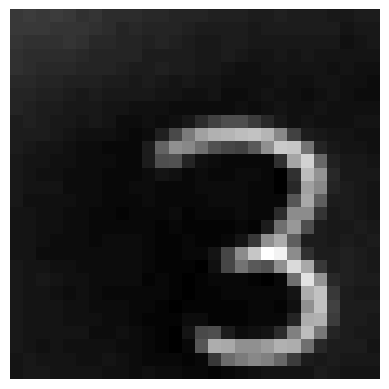

In [40]:
img_crop = img_gray.crop((450, 300, 800, 750))

plt.imshow(img_crop, cmap="gray")
plt.axis("off")

img_resize = img_crop.resize((28, 28))

plt.imshow(img_resize, cmap="gray")
plt.axis("off")

img_array = np.array(img_resize)

img_inverted = 255 - img_array

plt.imshow(img_inverted, cmap="gray")
plt.axis("off")
plt.show()

img_normalized = img_inverted / 255.0

In [41]:
img_input = img_normalized.reshape(1, 28, 28, 1)

print(img_input.shape)

(1, 28, 28, 1)


In [42]:
prediction = model.predict(img_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [43]:
predicted_digit = np.argmax(prediction)

confidence = np.max(prediction) * 100

print("Predicted digit:", predicted_digit)
print(f"Confidence: {confidence:.2f}%")

Predicted digit: 4
Confidence: 21.49%
